## Github Link: https://github.com/DariusTata/the-right-word

#### Notebook Contents

0. Title: Verifying *"Navigating Leadership Flexibility" (Tata, 2024, unpublished)*
1. Qualitatively Identified Themes
2. Manual Cleaning
3. Import Data as dataframe
4. Split text into utterances
5. Clean using code and Tokenize
6. Generate Vectors (TF-IDF)
7. Clustering (K-Means)
8. Clustering Assessment (Elbow Method)
9. Visualizing K-Means Clusters
10. Clustering Revisted (DBSCAN)
11. Visualizing DBSCAN Clusters
12. Comparing KMEANS and DBSCAN Clusters
13. Clustering Assessment Revisted (Silhouette Score)
14. Conclusion & Limitations

##### Import Libraries and define some 'global' variables

In [ ]:
#import libaries
import nltk
nltk.download('words')
from nltk.corpus import wordnet as wn

nltk.download('punkt')
from nltk.stem import WordNetLemmatizer #import the nltk lemmatizer
lemmatizer = WordNetLemmatizer() #rename the nltk lemmatizer
from nltk import stem
stemmer = stem.PorterStemmer()
from nltk import word_tokenize

nltk.download('stopwords')
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))
### create custom stopword list to remove junk from interview data
stops_custom = ['darius','tata','Darius','Tata',
                'bq','cd','gd','rh','sp','tb',
                'BQ','CD','GD','RH','SP','TB',
                '--','um','uh',"'s","'ve","'m","n't","'re",'im',"'ll"]
all_stops = stops.union(stops_custom)

import re #regex used for data cleaning

import string
punct = list(string.punctuation)
from collections import Counter

nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.metrics import edit_distance
from nltk.metrics import jaccard_distance #used to validate kmeans clustering

from nltk.corpus import words
from random import sample

import gensim #topic modelling library
from gensim.models.phrases import Phrases, Phraser #used in ngram generator "lemmas2ngrams()"

import pyLDAvis #LDA visualization
import pyLDAvis.gensim

import sklearn #library for tf-idf and k-means
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans #used to cluster tf-idf vectors
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt #tf-idf/k-means visualization
from sklearn.decomposition import PCA #dimensionality reduction for visualization

from sklearn.preprocessing import MinMaxScaler #elbow method
from sklearn.preprocessing import MaxAbsScaler #elbow method

from sklearn.cluster import DBSCAN #alternate function to cluster tf-idf vectors

from sklearn.metrics import silhouette_score #used for cluster assessment


import datetime #used for saving images of plots
#from getpass import getpass
import os #used for loading transcript files
import pandas as pd #dataframes library
import plotly.express as px #https://github.com/plotly/plotly.py/issues/4997
from plotly.subplots import make_subplots #used for subplot creation

import numpy as np #dataframes


# A secondary analysis of:
## *"Navigating Leadership Flexibility. How do technical leaders pick the right approach?" (Tata, 2024)*
This project performs a secondary analysis applying NLP to the word data I gathered for my undergraduate dissertation. This project  attempts to review and perhaps verify the themes identified during the primary analysis, where I undertook qualitative coding of the interview transcripts while pursuing a grounded theory methological approach.

#### Corpus Information
* A total of six interview transcripts were generated following semi-structured interviews of roughly 60 minutes each.
* Each interview was conducted by the same single interviewer, following a schedule devised following a literature review.
* The semi-structured interviews were based on an interview schedule of 24 questions across a total of four themes and eight sub-themes.
* Efforts have been made to anonomise the participants and limit tracable or identifiable data.
* The purposive sample consisted of six leaders who work in or with technology in UK-based companies.
* While the sample size limits generalisability, this project seeks to review and perhaps verify the themes which were qualitatively identified during primary analysis.
* Other key limitations due to sample size were gender bias (one female, five male particpants) and a lack of distinction between leaders based in the UK working in UK companies versus leaders based in the UK while working in English-speaking Multinational Corporations.

## 1. Qualitatively Identified Themes

#### Emergent Themes Previously Identified
Research Question: What affects or motivates a change in leadership style?
1. Use of Data
2. Social Perception and Cognition (Listening to People & Reading and Understanding People)
3. Declared Values<br>
3a. Individual Accountability<br>
3b. Trust in Others<br>
4. Differences in Authenticity<br>
4a. Group A: Authentically Rigid (Absolute Authenticity)<br>
4b. Group A<sub>1</sub>: Consistent Style with Changing Content and Format<br>
4c. Group B: Authentically Flexible<br>
4d. Group C: Authentically Adaptive<br>

| Theme<br>Index | Themes Previously Identified | Participants |
|-------------|------------------------------|--------------|
| 1 | Use of Data | TB, CD, RH |
| 2 | Social Perception and Cognition | BQ, CD, RH, GD |
| 3 / 4 | Declared Values: Individual Accountability / Trust in Others | - GD, BQ, RH, TB, CD / - GD, BQ, RH, TB, CD, SP|
| 5 / 6 / 7 / 8 | Differences in Authenticity: Group A: Authentically Rigid (Absolute Authenticity) / Group A<sub>1</sub>: Consistent Style with Changing Content and Format / Group B: Authentically Flexible / Group C: Authentically Adaptive| - BQ / - TB, SP / - RH / - CD, GD |

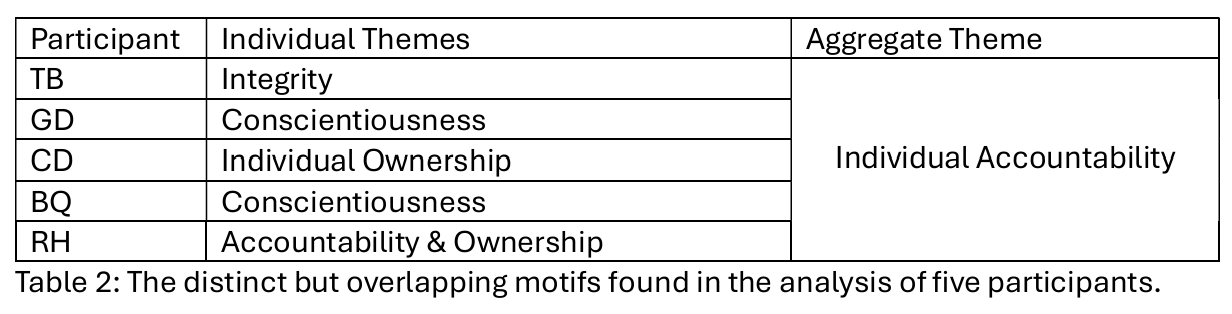  
(Image 1. This is an image of tables from my primary analysis paper. I initially reproduced this table in html/markdown for this project but converting the ipynb file to pdf resulted in formatting issues.)

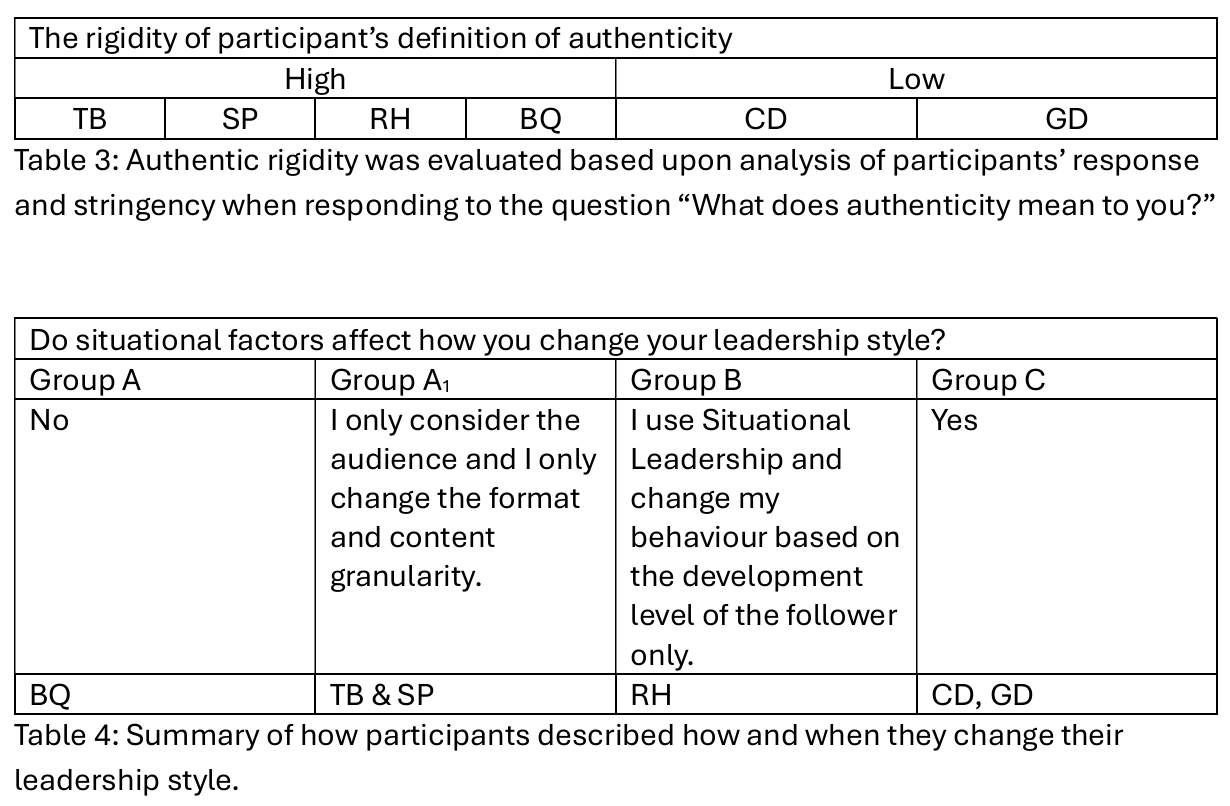  
(Image 2. This is an image of tables from my primary analysis paper. I initially reproduced these tables in html/markdown for this project but converting the ipynb file to pdf resulted in formatting issues.)

## 2. Manual Cleaning

### Manual data cleaning
Manual data cleaning is time-consuming and unweildy; thankfully I am aquainted with these transcripts from the qualitative analysis I've previously completed. Despite benefitting from the manual data cleaning I executed for the previous project, I still performed the following:
* Manually divided the six interview transcripts into a total 42 interview subsections.
* Manually verified each subsection's spacing and linebreaks were consistent.
* Manually verified the beginning of each speaking block began in consistent formatting. 

## 3. Import Data as dataframe

I created a dataframe with the participant ID, subsection name, subsection number, and subsection text.

In [ ]:
def get_files(dir):
    #Get list of all txt files in directory and subdirectories
    all_files = []
    for root, dirs, files in os.walk(dir):
        #print(f"\nChecking directory: {root}")
        #print("Found files:", files)
        for file in files:
            if file.endswith('.txt'):
                all_files.append(os.path.join(root, file))
                #print("Added file:", file_path)
    return(all_files)

In [ ]:
def process_interviews(dir):

    txt_files = get_files(dir)

    participant_ids =[] #Anon ID of each interviewee
    subtopic_names =[] #Name of interview subtopic
    subtopic_numbers =[] #Number of interview subtopic
    subtopic_texts=[] #Content of each subtopic file

    i=0
    for txt_file in txt_files:

        with open(txt_file, 'r') as f:
            subtopic_text = f.read()
        
        participant_id = os.path.basename(os.path.dirname(txt_file)) #each subtopic text is saved in a folder named after the participant.
        subtopic_name = os.path.splitext(os.path.basename(txt_file))[0]

        subtopic_number = int(subtopic_name.split()[1]) #each subtopic text's title has the subtopic number as it's first character

        participant_ids.append(participant_id)
        subtopic_names.append(subtopic_name)
        subtopic_texts.append(subtopic_text)

        subtopic_numbers.append(subtopic_number)
        i=i+1

    interview_dataframe = pd.DataFrame({
        'participant_id': participant_ids,
        'subsection#': subtopic_numbers,
        'subsection': subtopic_names,
        'text': subtopic_texts
    })

    #Sorts df by 'participant_id' and 'subtopic#'
    interview_dataframe = interview_dataframe.sort_values(['participant_id', 'subsection#'])

    #resets df index after sorting
    interview_dataframe = interview_dataframe.reset_index(drop=True) 

    return(interview_dataframe)


In [ ]:
interview_df = process_interviews("./transcripts")
print(f"Total subsections processed: {len(interview_df)}")
interview_df.head()

## 4. Split texts into utterances

I Split the 42 subsections into vastly more "utterances" to benefit TF-IDF topic modelling.

In [ ]:

def split_text(text):
    #Split on newline and exactly three digits. Manual data cleaning ensuring this consistent formatting assumption.
    pattern = r'\n\d{3}'
    fragments = re.split(pattern, text)
    
    #Remove first empty string and process utterances
    utterances = []
    for u in fragments[1:]:
        cleaned_u = u.strip()
        utterances.append(cleaned_u)
    
    return(utterances)


def process_utterances(interview_df):
    #Initialize lists to store utterance data
    utterance_participants = []
    utterance_stname = []
    utterance_stnum = []
    utterance_texts = []
    #utterance_timeless = []
    
    #Process each row in the interview dataframe
    i = 0
    for index, row in interview_df.iterrows():
        #Get utterances from this subtopic
        utterances = split_text(row['text'])
        
        #Store data for each utterance
        for utterance in utterances:
            utterance_participants.append(row['participant_id'])
            utterance_stname.append(row['subsection'])
            utterance_stnum.append(row['subsection#'])
            utterance_texts.append(utterance)
            #utterance_timeless.append(remove_timecodes(utterance))
            i = i + 1
    
    #Create dataframe from the lists
    utterance_dataframe = pd.DataFrame({
        'participant_id': utterance_participants,
        'subsection#': utterance_stnum,
        'subsection': utterance_stname,
        'utterance': utterance_texts
        #'timeless utterance': utterance_timeless
    })
    
    #Sort like the interview dataframe
    utterance_dataframe = utterance_dataframe.sort_values(['participant_id', 'subsection#'])
    
    #Reset index after sorting
    utterance_dataframe = utterance_dataframe.reset_index(drop=True)
    
    return(utterance_dataframe)


In [ ]:
utterance_df = process_utterances(interview_df)
print(f"Total utterances processed: {len(utterance_df)}")
utterance_df.head()

Next I filter out all of the interviewer's utterances from the dataframe. I take this action based in the assumption that the interviewer's utterances contain little informational content are therefore not interested in including them within the data for analysis. This assumption is not self-evident - it may be the case that analysis of the conversation as a whole contains relevant information, but this inquiry may be difficult to substantiate and is outside of the scope of this project. 

In [ ]:
# Print initial count
print(f"Original number of utterances: {len(utterance_df)}")

# Create mask for interviewer utterances
mask = []
for utterance in utterance_df['utterance']:
    utterance_lines = utterance.split('\n')
    is_interviewer = False
    for line in utterance_lines:
        if line.startswith("Darius Tata:"):
            is_interviewer = True
            break
    mask.append(is_interviewer)

# Drop the interviewer utterances
utterance_df.drop(utterance_df[mask].index, inplace=True)

# Reset the index
utterance_df.reset_index(drop=True, inplace=True)

# Print final count
print(f"Utterances after removing interviewer: {len(utterance_df)}")

utterance_df.head()

## 5. Clean using Code and Tokenize

In [ ]:
# In an earlier version of this codebook, I created a cleaning function called text2lemmas()
#  but it wasn't working for tf-idf. Since sklearn's tf-idf handles tokenization internally
#  I've written some simple cleaning below.
# Both these cleanining functions below and text2lemmas() reference the stops list declared
#  at the begining of this notebook, which includes a custom stops list.
#
def remove_stops(text, all_stops):
    words = text.split()
    final = []
    for word in words:
        if word not in all_stops:
            final.append(word)
    final = " ".join(final)
    final = final.translate(str.maketrans("", "", string.punctuation))
    final = "".join([i for i in final if not i.isdigit()])

    while "  " in final:
        final = final.replace("  ", " ")
    return(final)


def clean_docs(docs):
    #stops = stopwords.words("english")
    final = []
    for doc in docs:
        doc = doc.lower()
        clean_doc = remove_stops(doc, all_stops)
        final.append(clean_doc)
    return(final)


In [ ]:
# While the cleaning functions I wrote do remove punctuation and unwanted junk characters
#  it doesn't seem to remove all my stopwords (eg "Tata"). During debugging I found passing
#  the corpus back through the clean_docs() function removed the tenacious stopwords.
#
# The code that follows "cleans" corpus_raw, and then "cooks" cleaned_docs.
# This method seemingly works. Perhaps I will revist this bug if I have time.

corpus_raw = []
cleaned_docs =[]
cooked_docs =[]

for text in utterance_df['utterance']: #creating corpus from interview_df dataframe
    corpus_raw.append(text)

cleaned_docs = clean_docs(corpus_raw)

'''
### START DEBUGGING ###
print(corpus_raw[0][:100])
print(cleaned_docs[10][:100])
print(cleaned_docs[10][:100])
### END DEBUGGING ###

cooked_docs = clean_docs(cleaned_docs)
utterance_df['cooked'] = cooked_docs #add the docs to the df as a new column 'cooked'

### START DEUGGING ###
print(corpus_raw[0][:100])
print(cooked_docs[10][:100])
print(cooked_docs[10][:100])
### END DEBUGGING ###
'''

In [ ]:
utterance_df.head()

## 6. Generate Vectors (TF-IDF)

TF-IDF is a function which generates vectors that measure the degree to which a term is used in a document, relative to the corpus. In this case it will be measuring the degree to which a tokenized word is used in an utterance, relative to the corpus of utterances.

In [ ]:
# Itialise the tf-idf vectorizer from sklearn
vectorizer = TfidfVectorizer(lowercase=True,
                             max_features=100,
                             max_df=1.0, #ignore words which occur in this proportion of the corpus
                             min_df=1, #ignore words which occur fewer than this number of times
                             ngram_range=(1,3), #monograms through to trigrams
                             stop_words="english") #limited stopword list options

In [ ]:
vectors = vectorizer.fit_transform(cooked_docs) #generate vectors using the sklearns tf-idf vectorizer on the "cooked" corpus.

terms = vectorizer.get_feature_names_out()

## 7. Clustering (K-Means)

K-means clustering aims to identify clusters within data by reducing the varition within each cluster. K-means clustering specifically attempts to put the data into the number of clusters requested. K-means clustering forces every document to conform to one topic.


In [ ]:
true_k = 8 #number of clusters sought
model = KMeans(n_clusters=true_k,
               init="k-means++",
               max_iter=100,
               n_init=1)

model.fit(vectors)

order_centroids = model.cluster_centers_.argsort()[:, ::-1]

#write resulting clusters to text file
with open ("kmeans_ugr_results.txt", "w") as f:
    for i in range(true_k):
        f.write(f"Cluster {i}")
        f.write("\n")
        for ind in order_centroids[i, :10]:
            f.write(' %s' % terms[ind],)
            f.write("\n")
        f.write("\n")
        f.write("\n")

## 8. Clustering Assessment (Elbow Method)

Since K-Means takes the number of clusters as a parameter, how can we determine what is a suitable number of clusters to pass to the function? Too few clusters over-emphasises the original study as a single cohesive unit, whereas too many clusters risks needless sub-divisions of topics.<br>
In my code I chose 8 as my sought number of clusters as this was the number of subthemes identified in primary analysis (which were subsequently collapsed into four themes), but is there a 'more objective' method to pick a value for K? One way to test this is the Eblow Method, where the value for K (number of clusters) at the 'elbow' inflection point of the graph of K against SSE (Sum of Squared Error), which can be taken as the number of clusters which balances the number of clusters and the distinctiveness of those clusters.

In [ ]:
scaler = MaxAbsScaler() #Scales each feature by dividing by its max absolute value
                        # keeping values between -1 and 1. Does NOT shift mean to 0.
                        # Appropriate for TF-IDF
x_scaled = scaler.fit_transform(vectors)
k_rg = range(2,32)


In [ ]:
kmeans_results = []

for k in k_rg:
    km2 = KMeans(n_clusters=k, random_state=42)
    labels = km2.fit_predict(x_scaled)
    score = silhouette_score(vectors, labels, metric='cosine')
    
    kmeans_results.append({
        'Number of Clusters (K)': k,
        'score': score,
        'Inertia (SSE)': km2.inertia_
    })

km2_df = pd.DataFrame(kmeans_results).sort_values('Number of Clusters (K)', ascending=False)

In [ ]:
km_small_fig = px.line(km2_df, x='Number of Clusters (K)', y='Inertia (SSE)', markers=True, title='K-means Elbow Plot')
km_small_fig.show()

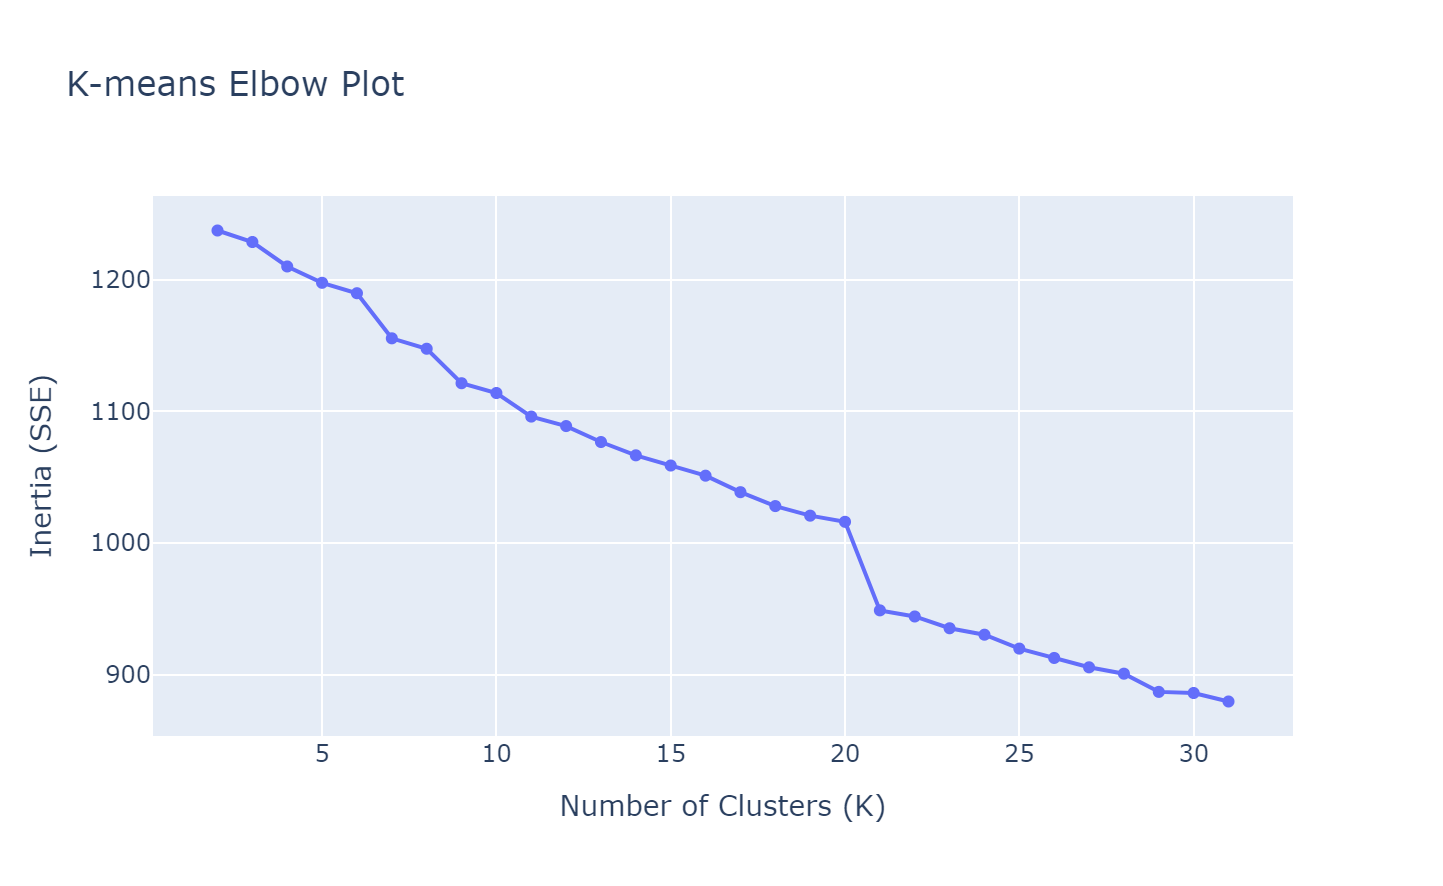  
(Image 3. K-Means Elbow Plot. This image is a screenshot of the above plot which is being included due to issues retaining plotly graphs upon file conversion to pdf)

##### Elbow Plot Key Takeaways
The Elbow Method is predicated on seeing a logarithmic curve when plotting K (number of clusters) against SSE (Sum of Squared Errors). It would be difficult to interpret the above line as a logarithmic curve. More notable still are the large spikes in variation away from the trend line. Together these two indications suggest this plot shows local maxima for K, but that the plot's resolution is too low to observe the logarithmic relationship. Next I run the same code but for 300 iterations instead of 30 in an attempt to see the expected curve shape of the logarithmic relationship.

In [ ]:
k_rg_big = range(2,302)
kmeans_results_big=[]

for k in k_rg_big:
    km_big = KMeans(n_clusters=k, random_state=42)
    labels = km_big.fit_predict(x_scaled)
    score = silhouette_score(vectors, labels, metric='cosine')
    
    kmeans_results_big.append({
        'Number of Clusters (K)': k,
        'score': score,
        'Inertia (SSE)': km_big.inertia_
    })

km_big_df = pd.DataFrame(kmeans_results_big).sort_values('Number of Clusters (K)', ascending=False)

In [ ]:
km_big_fig = px.line(km_big_df, x='Number of Clusters (K)', y='Inertia (SSE)', markers=True, title='Big K-means Elbow Plot')
km_big_fig.show()

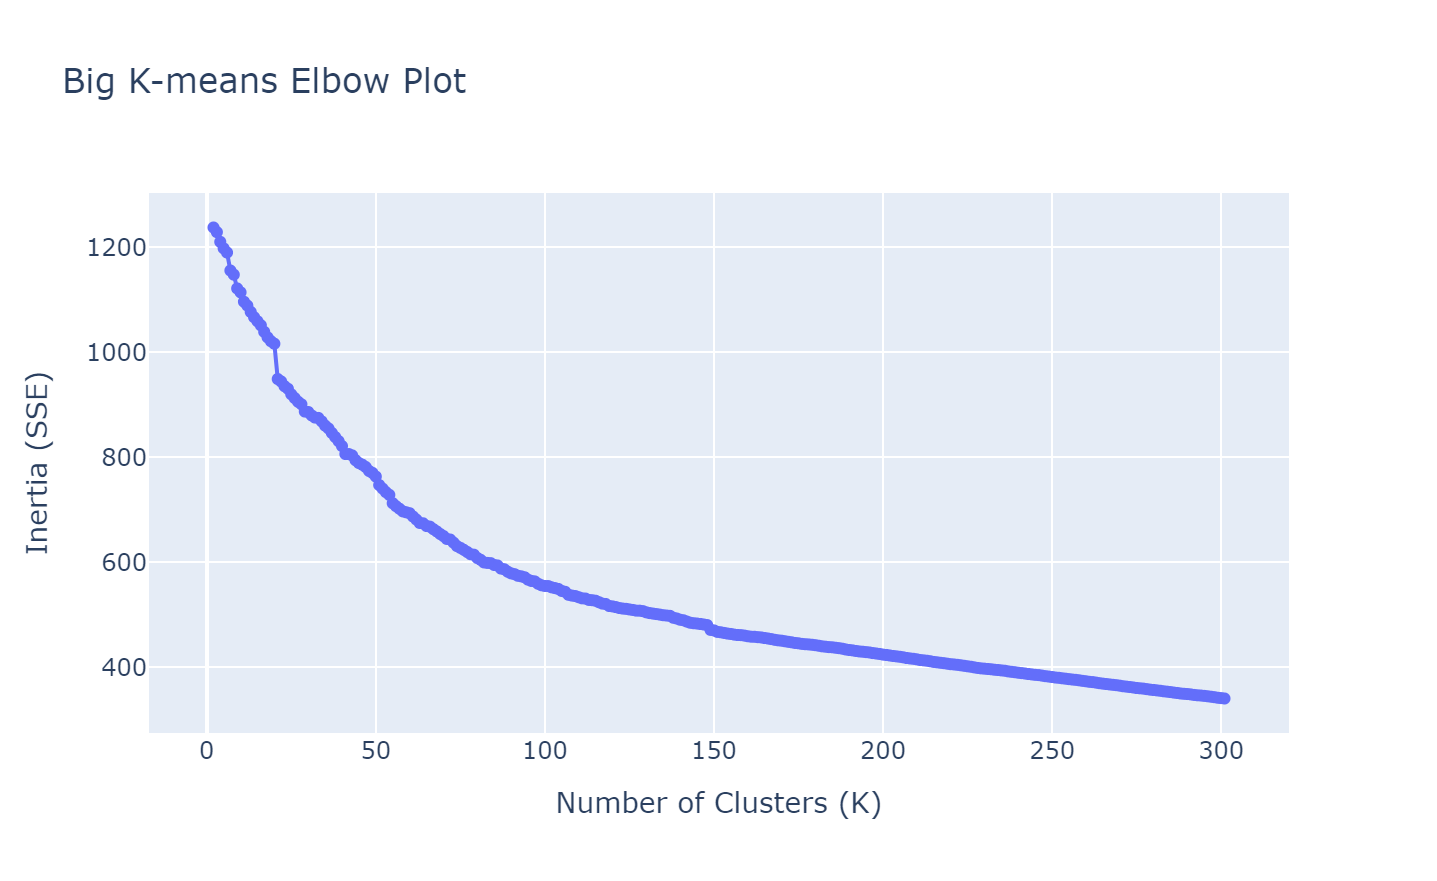  
(Image 4. K-Means Elbow Big Plot. This image is a screenshot of the above plot which is being included due to issues retaining plotly graphs upon file conversion to pdf)

##### Big Plot Key Takeaways
Analysing the Big Plot by eye, the most notable influction points occur between the following K values:

| Table Index | Inflection Point |
|-------------|------------------|
| 1 | 6 to 7 |
| 2 | 8 to 9 |
| 3 | 10 to 11 |
| 4 | 20 to 21 |
| 5 | 40 to 41 |
| 6 | 54 to 55 |
| 7 | 148 to 149 |
  
This plot therefore suggests the optimum point in my data for number of clusters vs SSE reduction is 149. This however seems to me to be entirely too many topics.

Next I verify $K=149$ being the optimum point by using the KneeLocator function from the kneed library.

In [ ]:
from kneed import KneeLocator

def find_elbow(km_dataframe):
    # Example data (replace with your SSE values)
    K=[]
    SSE=[]
    K = km_dataframe['Number of Clusters (K)']
    SSE = km_dataframe['Inertia (SSE)']  # Example inertia values

    # Use KneeLocator
    kneedle = KneeLocator(K, SSE, curve="convex", direction="decreasing")

    return(kneedle.knee)

# Print the elbow point
elbow = find_elbow(km_big_df)
print(f"Optimal number of clusters (K): {elbow}")


#### Interpreting the Elbow
Based on my qualitative analysis and intimate association with the source data in question, I am going to discard this result $(K=149)$ in favour of finding local maxima within a reasonable range. This brings focus to the first three inflection points for K I noted $(K=6\to7,8\to9,10\to11)$ as a number of clusters closer to the number of themes I identified in primary analysis, and therefore aligns with the stated aim of this project as primary analysis verification.

## 9. Visualizing K-Means Clusters (2D and 3D)

### Principal Comonent Analysis (PCA)
Since the tf-idf vectors are represented in spatial dimensions greater than three, this poses a problem for interpretation. In this next section I use Principal Component Analysis (PCA) from the sklearn library to "squash" the dimensions into human-interpretable levels. While this reduction of dimensionality means a loss of detail, it allows for pattern identification by eye.

In [ ]:
kmean_indicies = model.fit_predict(vectors)
utterance_df['Cluster'] = kmean_indicies #store cluster numbers in the dataframe
pca_2= PCA(n_components=2) #two dimensions for Principal Component Analysis
pca_3= PCA(n_components=3) #three dimensions

#Perform PCA (ie "squash" dimensionality)
scatter_plot_points_2d = pca_2.fit_transform(vectors.toarray())
scatter_plot_points_3d = pca_3.fit_transform(vectors.toarray())

short_utterances = [] #create shortened utterances for display in the plots
for utterance in utterance_df['utterance']:
    cleaned = re.sub(r'\d{2}:\d{2}:\d{2}\.\d{3}', '', utterance) #remove timecode from utterance text
    cleaned = re.sub(r'\d{2}:\d{2}:\d{2}\,\d{3}', '', cleaned) #remove alternate timecode format
    cleaned = re.sub(r'-->', '', cleaned) #remove arrow from timecode
    cleaned = re.sub(r'\d{2}:\d{2}:\d{2}', '', cleaned) #remove second alt timecode format.
                                                        #this shorter alt format must be removed AFTER the longer formats
    cleaned = ' '.join(cleaned.split()) #remove extra space characters
    shortened = cleaned[:50] + '...' #shorten utterance to first 50 characters for readability within the plot
    short_utterances.append(shortened)

#create dataframe from 2d points
pc_df_2d = pd.DataFrame(data=scatter_plot_points_2d, 
                        columns=
                        ['PC'+str(i) for i in range(1, 3)])
pc_df_2d['subsection'] = utterance_df['subsection#']  # Add subsection for hover data
pc_df_2d['utterance'] = short_utterances #pull utterance from the column without the timecodes
pc_df_2d['participant'] = utterance_df['participant_id']

#create dataframe from 3d points
pc_df_3d = pd.DataFrame(data=scatter_plot_points_3d, 
                        columns=
                        ['PC'+str(i) for i in range(1, 4)])
pc_df_3d['subsection'] = utterance_df['subsection#']  # Add subsection for hover data
pc_df_3d['utterance'] = short_utterances #pull utterance from the df column without the timecodes
pc_df_3d['participant'] = utterance_df['participant_id']


### Plotting the PCA data
Here I plot the two PCA datasets using plotly: `pc_df_2d` for the two component PCA data, and `pc_df_3d` for the three component PCA data.

In [ ]:
km_cluster_labels = [f'Cluster {i}' for i in kmean_indicies]

#2D clustering from data
km_fig_2d = px.scatter(data_frame=pc_df_2d, 
                    x='PC1', y='PC2', 
                    color=km_cluster_labels,
                    hover_data=['subsection'],
                    color_discrete_sequence=px.colors.qualitative.Set1,
                    labels={'colour': 'Cluster'},
                    custom_data=[km_cluster_labels, 'participant', 'subsection', 'utterance'])


# Create 3D scatter plot
km_fig_3d = px.scatter_3d(data_frame=pc_df_3d, 
                    x='PC1', y='PC2', z='PC3', 
                    color=km_cluster_labels,
                    hover_data=['subsection'],
                    color_discrete_sequence=px.colors.qualitative.Set1,
                    labels={'colour': 'Cluster'},
                    custom_data=[km_cluster_labels, 'participant', 'subsection', 'utterance'])

km_fig_3d.update_traces(marker=dict(size=5, line=dict(width=2, color='DarkSlateGrey')),
                 selector=dict(mode='markers'))


# Create subplot figure
km_fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'scene'}]],
    subplot_titles=('2D Visualization', '3D Visualization'),
    column_widths=[0.5,0.5]
)

# Add traces from both figures
for trace in km_fig_2d.data:
    km_fig.add_trace(trace, row=1, col=1)

for trace in km_fig_3d.data:
    km_fig.add_trace(trace, row=1, col=2)


km_fig.update_traces(
    hovertemplate="<br>".join([ #Mixing standard parameters and the custom data parameter didn't seem to work correctly
                                # so I'm passing all the hover data through the custom data parameter.
        '%{customdata[0]}', #Cluster 
        'ID: %{customdata[1]}', #Participant  
        'Subsection: %{customdata[2]}', #Subsection 
        'Text: %{customdata[3]}' #Utterance with timecodes removed
    ])
)


# Update layout
km_fig.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    title_text="2D and 3D Cluster Visualizations"
)

km_fig.show()

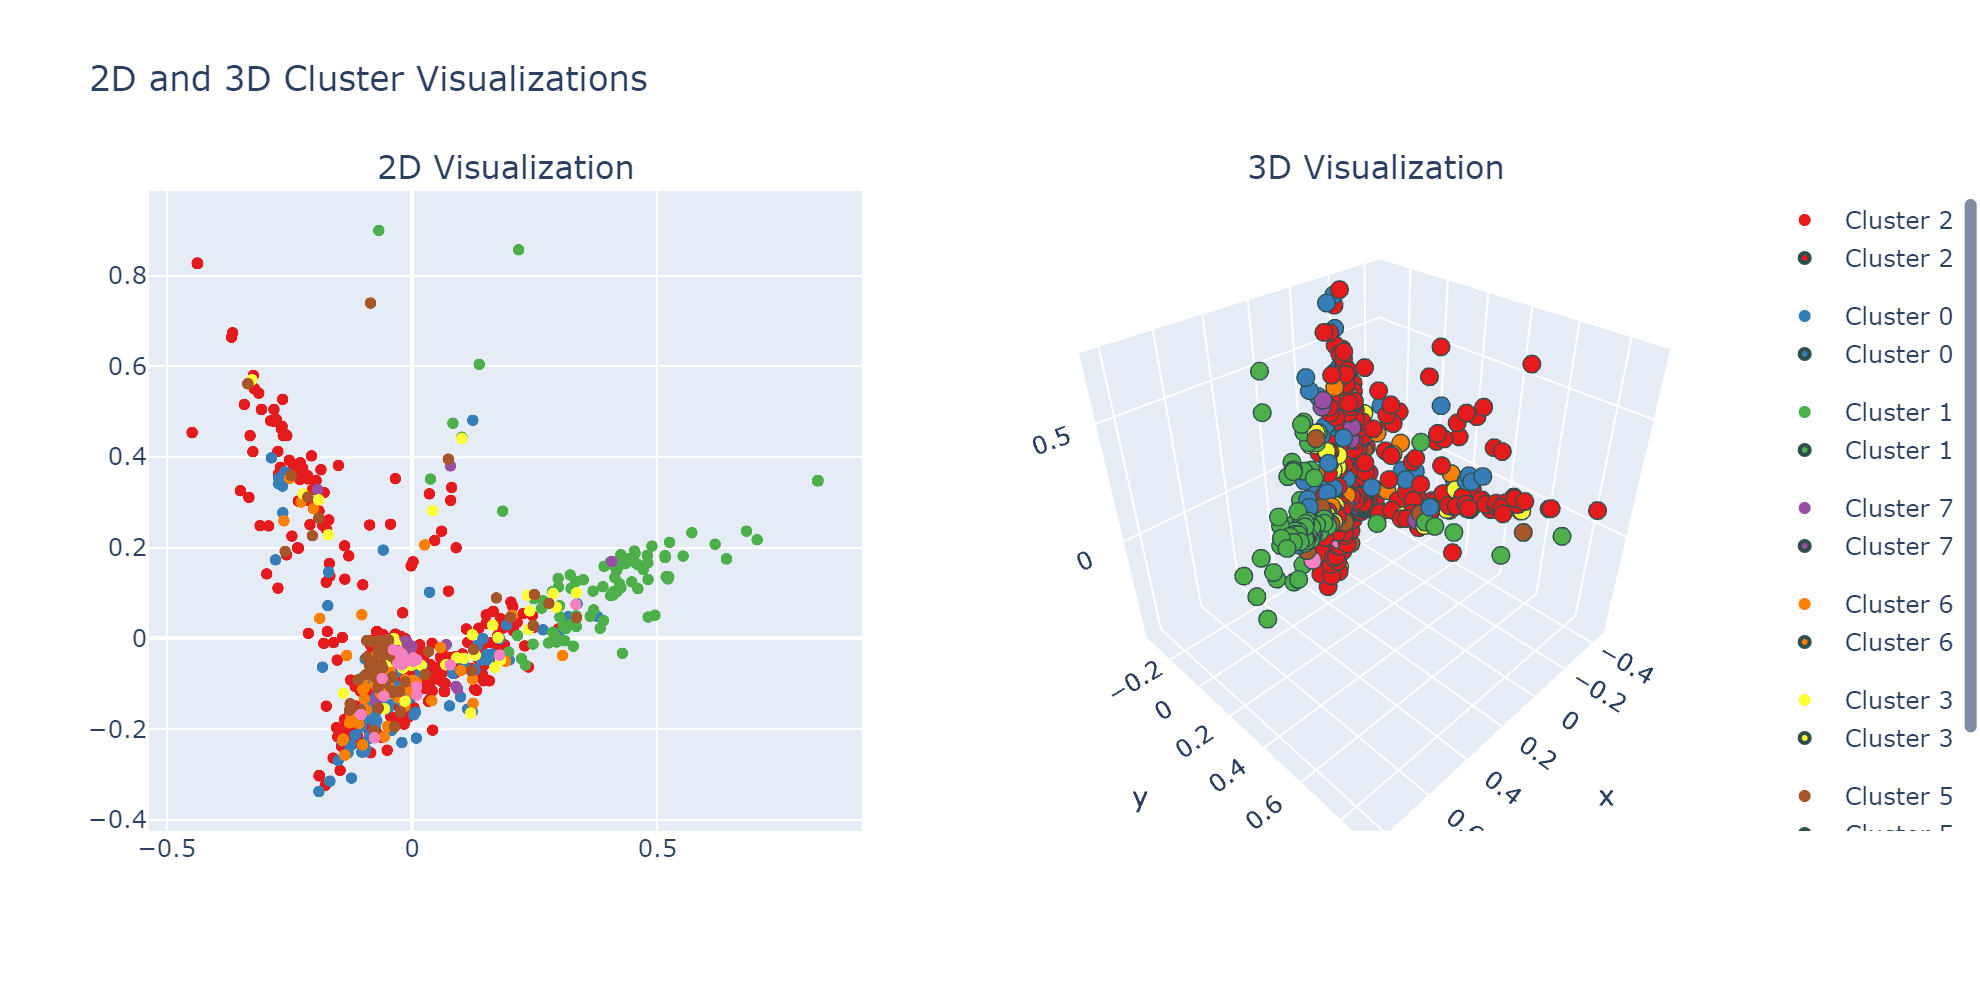  
(Image 5. 2D and 3D Cluster Visualizations. This image is a screenshot of the above plot which is being included due to issues retaining plotly graphs upon file conversion to pdf)

## 10. Clustering revisted (DBSCAN)

There is still a fair amount of uncertainty around if the K-Means clustering is appearing due to researcher bias. I set the number of clusters based on findings from primary analysis and so how can we be sure the resultant visualtisations are not simply an exercise in confirmation bias?

In this section I will be using DBSCAN as alternative clustering function which does not require the number of clusters to be given as a parameter in an attempt to verify the findings from K-Means. 

In [ ]:
# Initialize DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine')  # 'cosine' works well for text data

# Fit the DBSCAN model
dbscan.fit(vectors)

DBS_labels = dbscan.labels_ #Retrieve cluster labels

# Display clustering results
#print("Cluster Labels:", DBS_labels)

DBS_terms = vectorizer.get_feature_names_out() #extract cluster contents

'''
    #here I am trying to generate a txt file which contains the clusters and their most associated terms
    # in the same way that kmeans_results.txt is produced.
    # But due to the difference in functionality, different approaches are needed. This is a 'nice to have'
    # feature which I may revist if I have time.
    
# Get number of clusters (accounting for noise points labeled as -1)
n_clusters = len(set(DBS_labels)) - (1 if -1 in DBS_labels else 0)

# Write results to text file
with open("dbscan_results.txt", "w") as f:
        # Handle all clusters including noise (-1) through to n-1
    for i in range(-1, n_clusters):
        f.write(f"Cluster {i}")
        f.write("\n")
        terms = [DBS_terms[j] for j, label in enumerate(DBS_labels) if label == i][:10]
        for term in terms:
            f.write(f' {term}')
            f.write('\n')
        f.write('\n')
        f.write('\n')    


print("Length of DBS_terms:", len(DBS_terms))
print("Length of DBS_labels:", len(DBS_labels))                
'''

## 11. Visualizing DBSCAN Clusters (2D and 3D)

In [ ]:
# Create cluster labels, handling noise points (-1) as "Noise"
dbs_cluster_labels = ['Noise' if label == -1 else f'Cluster {label}' for label in DBS_labels]

# 2D clustering from data
dbs_fig_2d = px.scatter(data_frame=pc_df_2d, 
                    x='PC1', y='PC2', 
                    color=dbs_cluster_labels,
                    hover_data=['subsection'],
                    color_discrete_sequence=px.colors.qualitative.Set1,
                    labels={'colour': 'Cluster'},
                    custom_data=[dbs_cluster_labels, 'participant', 'subsection', 'utterance'])


# Create 3D scatter plot
dbs_fig_3d = px.scatter_3d(data_frame=pc_df_3d, 
                    x='PC1', y='PC2', z='PC3', 
                    color=dbs_cluster_labels,
                    hover_data=['subsection'],
                    color_discrete_sequence=px.colors.qualitative.Set1,
                    labels={'colour': 'Cluster'},
                    custom_data=[dbs_cluster_labels, 'participant', 'subsection', 'utterance'])

dbs_fig_3d.update_traces(marker=dict(size=5, line=dict(width=2, color='DarkSlateGrey')),
                 selector=dict(mode='markers'))


# Create subplot figure
dbs_fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'scene'}]],
    subplot_titles=('2D Visualization', '3D Visualization'),
    column_widths=[0.5,0.5]
)

# Add traces from both figures
for trace in dbs_fig_2d.data:
    dbs_fig.add_trace(trace, row=1, col=1)

for trace in dbs_fig_3d.data:
    dbs_fig.add_trace(trace, row=1, col=2)


dbs_fig.update_traces(
    hovertemplate="<br>".join([
        '%{customdata[0]}', #Cluster 
        'ID: %{customdata[1]}', #Participant  
        'Subsection: %{customdata[2]}', #Subsection 
        'Text: %{customdata[3]}' #Utterance with timecodes removed
    ])
)


# Update layout
dbs_fig.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    title_text="DBSCAN 2D and 3D Cluster Visualizations"
)

dbs_fig.show()

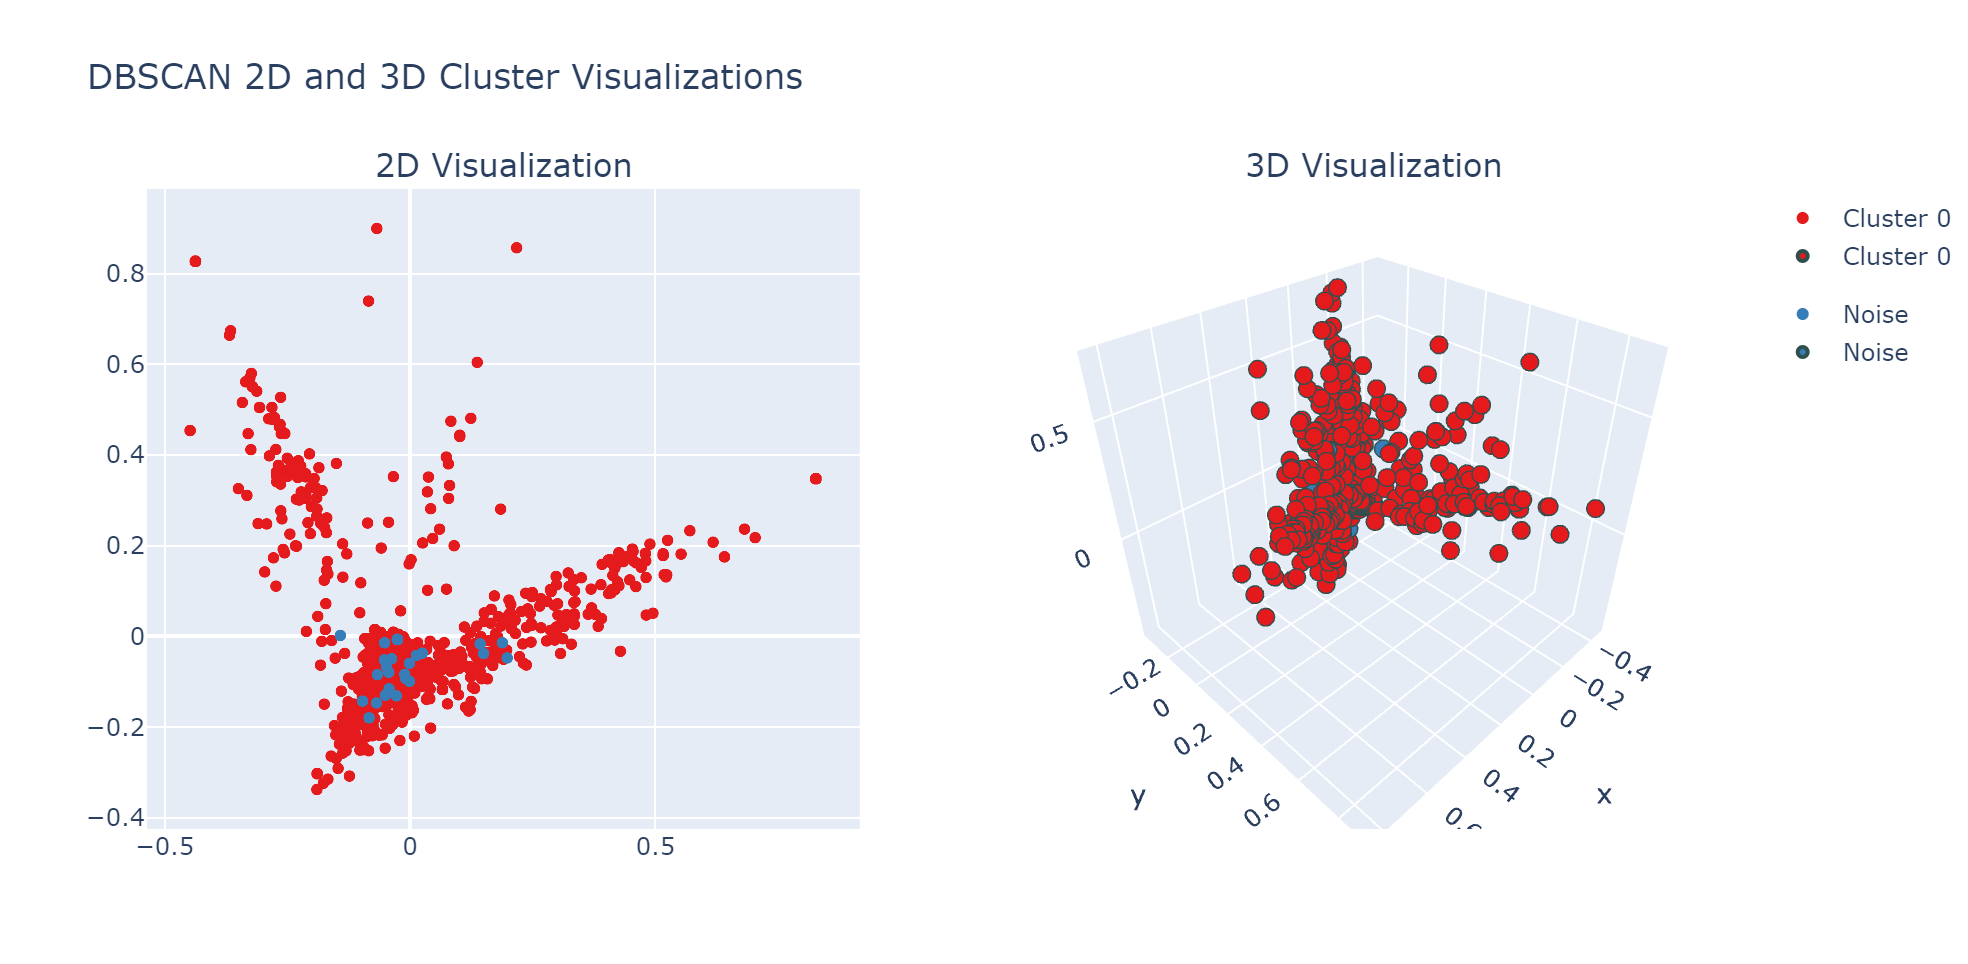  
(Image 6. DBSCAN 2D and 3D Cluster Visualizations. This image is a screenshot of the above plot which is being included due to issues retaining plotly graphs upon file conversion to pdf)

#### DBSCAN Interpretation
The results from DBSCAN are shocking - only one cluster is identified along with some noise. Two things strike me seeing this visualization:  
1. What are the noise points, and how have they been clustered by K-Means?  
2. If DBSCAN doesn't take number of clusters as an argument, what does it take? And do these influence the number of clusters identified?

Point 1: I investigate this the next section by comparing K-Means and DBSCAN plots side-by-side.<br>
Point 2: While I did explore this, my findings indicatated that the function can be manipulated in similar but different ways to K-Means in pursit of an output of a desired number of clusters. I have included a limited write up of my exploration in this notebook as I deemed fuller a investigation out of scope for this project.

## 12. Comparing KMeans and DBSCAN Clusters side-by-side (Visualizing PCA data)

In [ ]:
# 1x2 subplot for 2D plots (K-means 2D and DBSCAN 2D)
fig_2d = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'xy'}]],
    subplot_titles=('K-means 2D', 'DBSCAN 2D'),
    column_widths=[0.5, 0.5]
)

# Add K-means 2D traces to (1,1)
for trace in km_fig_2d.data:
    trace.name = 'KM' + str(trace.name) #append name coming from the df with model name
                                        # otherwise the legend has multiple "cluster 0" for example
    fig_2d.add_trace(trace, row=1, col=1)

# Add DBSCAN 2D traces to (1,2)
for trace in dbs_fig_2d.data:
    trace.name = 'DBS' + str(trace.name)
    fig_2d.add_trace(trace, row=1, col=2)

# Update layout for 2D figure
fig_2d.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    title_text="2D Comparison: K-means vs DBSCAN",
    legend=dict(
        groupclick="toggleitem",
        tracegroupgap=0,
        y=0.5
    )
)

# 1x2 subplot for 3D plots (K-means 3D and DBSCAN 3D)
fig_3d = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=('K-means 3D', 'DBSCAN 3D'),
    column_widths=[0.5, 0.5]
)

# Add K-means 3D traces to (1,1)
for trace in km_fig_3d.data:
    trace.name = 'KM' + str(trace.name)
    fig_3d.add_trace(trace, row=1, col=1)

# Add DBSCAN 3D traces to (1,2)
for trace in dbs_fig_3d.data:
    trace.name = 'DBS' + str(trace.name)
    fig_3d.add_trace(trace, row=1, col=2)

# Update layout for 3D figure
fig_3d.update_layout(
    height=500,
    width=1000,
    showlegend=True,
    title_text="3D Comparison: K-means vs DBSCAN",
    legend=dict(
        groupclick="toggleitem",
        tracegroupgap=30,
        y=0.5
    )
)

# Display both figures
fig_2d.show()
fig_3d.show()

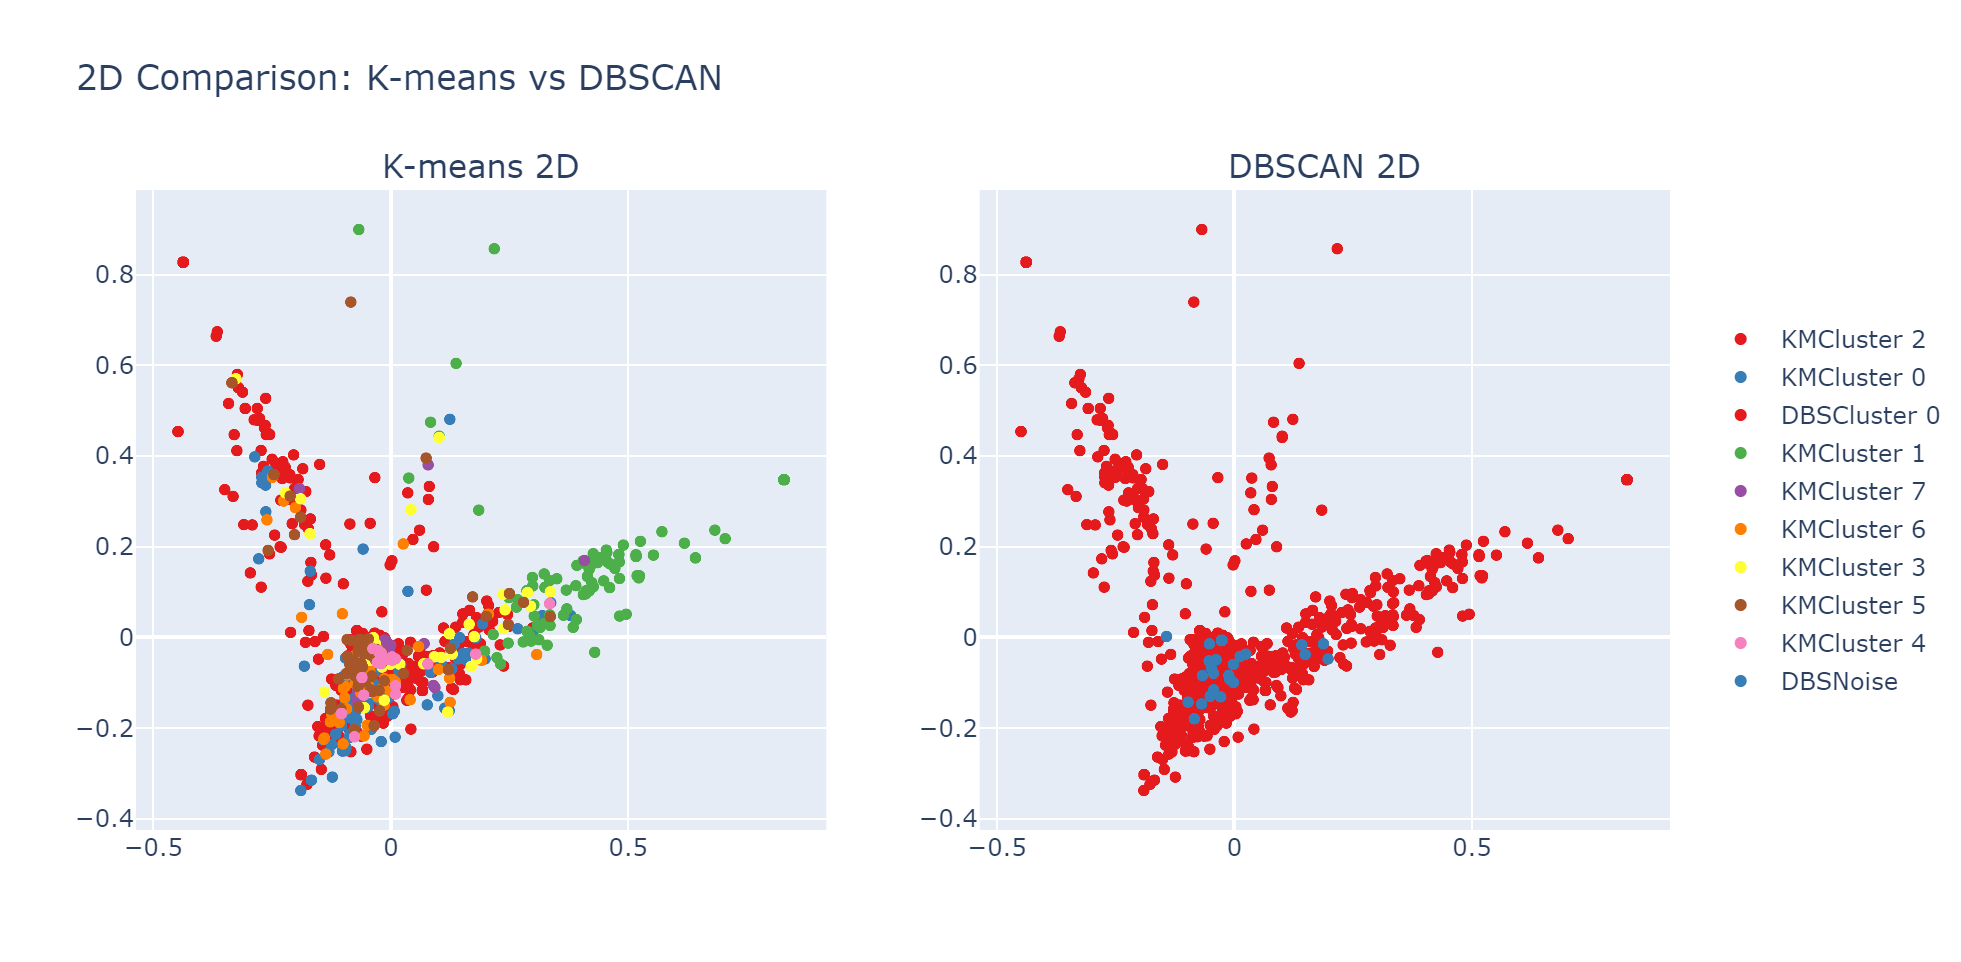
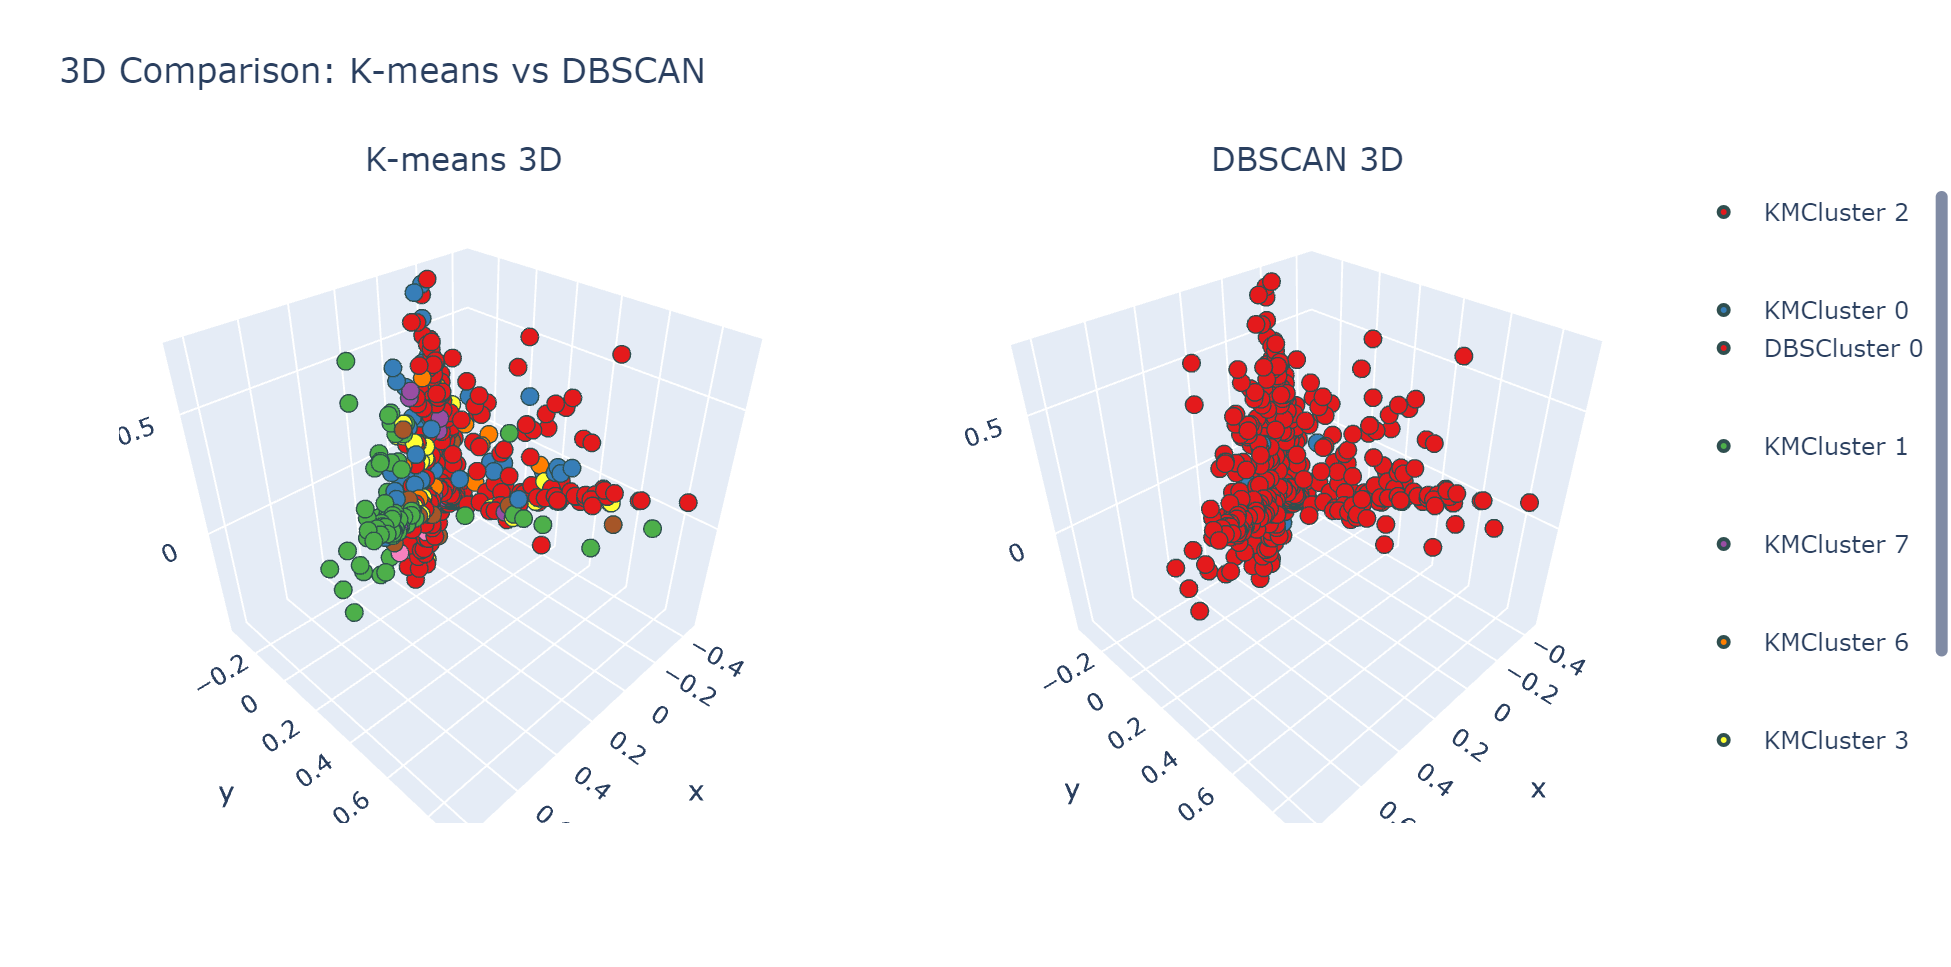  
(Image 7. 2D and 3D Comparison of K-Means vs DBSCAN. These two images are screenshots of the above plots which are being included due to issues retaining plotly graphs upon file conversion to pdf)

##### Clustering Method Comparison Key Takeways
The key distinction I can make is that although DBSCAN doesn't directly take a desired number of clusters as an argument, it is not more or less 'bias proof' in so far as it's arugments Epsilon (`eps`) and Min Samples (`min_samples`) effectively control the number of clusters produced. Upon further research I can conclude the main differences are in their model assumptions and are as follows:

| Assumption  | K-Means | DBSCAN |
|-------------|---------|--------|
| *Cluster Shape* | Clusters are roughly spherical | Clusters can be any shape |
| *Cluster Density* | Clusters are similar in size/density | Clusters are regions of high density separated by regions of low density |
| *Cluster Assignment* | Every point belongs to a cluster | Not all points need to belong to a cluster |

## 13. Clustering Assessment revisited (Silhouette Score)


The side-by-side comparison between the K-means clustering and DB Scan clustering appears to indicate 

In [ ]:
# For K-means results
km_score = silhouette_score(
    X=vectors,
    labels=km_cluster_labels,
    metric='cosine'
)

# For DBSCAN results
dbs_score = silhouette_score(
    X=vectors,
    labels=dbs_cluster_labels,
    metric='cosine'
)

print(f'K-means Silhouette Score: {km_score:.3f}')
print(f'DBSCAN Silhouette Score: {dbs_score:.3f}')

##### Interpreting Silhouette Scores

| Clustering Algorithm | Silhouette Score |
|----------------------|------------------|
| *ExampleScores* | *&nbsp;&nbsp;1 is total separation*<br>*&nbsp;&nbsp;0 is total overlap*<br>*&nbsp;-1 is total misclassifcation* | 
| K-Means | ~0.069 |
| DBSCAN | ~0.038 |

These are very close to zero, meaning the clusters are highly overlapping. This is expected for DBSCAN, as it only identified two clusters, cluster 1 and noise, and can observe the overlap in the plots. Such a low score for K-Means however indicates caution should be used during analysis to avoid mis or over-interpreting the results. Next I run the silhouette score iteratively to see what parameter values for KMeans and DBscan improve their silhouette scores, and therefore may uncover so far unidentified clusters.

In [ ]:
# Parameters
k_range = range(2, 31)
eps_range = [0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
min_samples_range = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# Store results
kmeans_results = []
dbscan_results = []

# K-means iteration
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(vectors)
    score = silhouette_score(vectors, labels, metric='cosine')
    
    kmeans_results.append({
        'k': k,
        'score': score,
        'inertia': kmeans.inertia_
    })

kmeans_df = pd.DataFrame(kmeans_results).sort_values('k', ascending=False)


# Create K-means Silhouette Score figure
kmeans_silhouette_fig = px.line(
    kmeans_df, x="k", y="score", markers=True,
    title="K-means Silhouette Scores",
    labels={"k": "Number of Clusters (K)", "score": "Silhouette Score"}
)

# Create K-means Elbow Plot figure
kmeans_elbow_fig = px.line(
    kmeans_df, x="k", y="inertia", markers=True,
    title="K-means Elbow Plot",
    labels={"k": "Number of Clusters (K)", "inertia": "Inertia (SSE)"}
)

In [ ]:
# Create 1x2 subplot
silhouette_elbow_fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('K-means Silhouette Scores', 'K-means Elbow Plot'),
    column_widths=[0.5, 0.5]
)

# Add Silhouette Score traces
for trace in kmeans_silhouette_fig.data:
    silhouette_elbow_fig.add_trace(trace, row=1, col=1)

# Add Elbow Plot traces
for trace in kmeans_elbow_fig.data:
    silhouette_elbow_fig.add_trace(trace, row=1, col=2)

# Update layout
silhouette_elbow_fig.update_layout(
    height=500, width=1000,
    showlegend=True,
    title_text="K-means Clustering Analysis",
    legend=dict(
        groupclick="toggleitem",
        tracegroupgap=30,
        y=0.5
    )
)

silhouette_elbow_fig.update_xaxes(title_text="Number of Clusters (K)", row=1, col=1)
silhouette_elbow_fig.update_yaxes(title_text="Silhouette Score", row=1, col=1)

silhouette_elbow_fig.update_xaxes(title_text="Number of Clusters (K)", row=1, col=2)
silhouette_elbow_fig.update_yaxes(title_text="Sum of Squared Errors", row=1, col=2)

silhouette_elbow_fig.show()

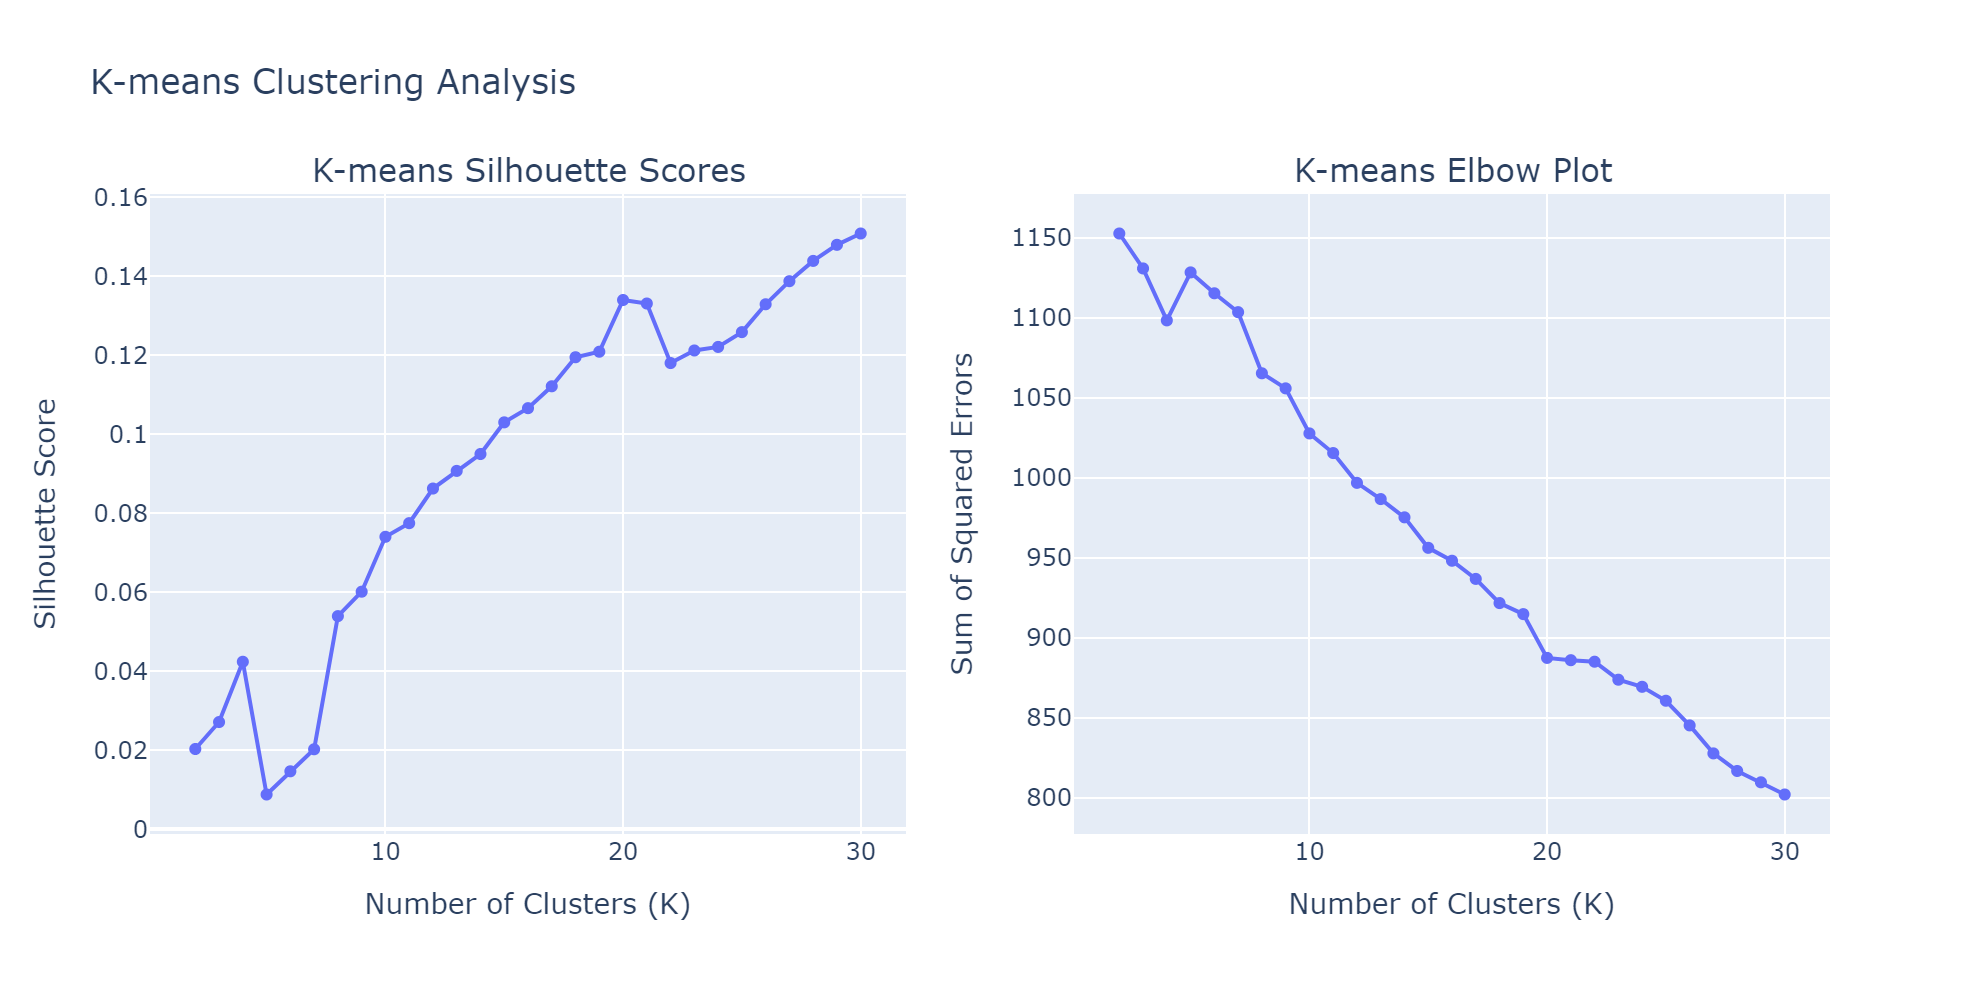  
(Image 8. K-Means Silhouette Score vs Elbow Method. This image is a screenshot of the above plot which is being included due to issues retaining plotly graphs upon file conversion to pdf)

### Extending the Elbow Method (SSE vs Silhouette Score)
The graphs above indicate there is a trade-off to be made; as the number of clusters K increases, SSE decreases and Silhouette Score increases, however the relationship between SSE decrease and Silhouette Score increase is non-linear.

In this section I will consider the improvement in Silhouette Score divided by the improvment in SSE as an 'improvement ratio':

* $Silhouette\,Change\,rate = \frac{\Delta\,Silhouette\,Score}{\Delta\,Number\,of\,Clusters\,(K)}$


* $Inertia\,Change\,rate = \frac{\Delta\,Inertia}{\Delta\,Number\,of\,Clusters\,(K)}$


* $Improvement\,Ratio = \frac{\Delta\,Silhouette\,Change\,rate}{\Delta\,Inertia\,Change\,rate}$


A second method for determining the optimum trade-off could be calculating the pareto front. While I explored this option I have since determined it is outside the scope of this project.

In [ ]:
cluster_metrics = kmeans_df[kmeans_df['k'].between(2, 15)].copy() # Filter for k between 2 and 15
cluster_metrics = cluster_metrics.sort_values('k') #sort df by k

# Calculate changes between consecutive points
cluster_metrics['inertia_change'] = -cluster_metrics['inertia'].diff()  # Negative diff since we want to maximize reduction
                                                                        #  and decrease in inertia is desirable
cluster_metrics['score_change'] = cluster_metrics['score'].diff()
cluster_metrics['cluster_size_change'] = cluster_metrics['k'].diff()

# Calculate rates of change (derivatives)
cluster_metrics['inertia_change_rate'] = cluster_metrics['inertia_change'] / cluster_metrics['cluster_size_change']
cluster_metrics['silhouette_change_rate'] = cluster_metrics['score_change'] / cluster_metrics['cluster_size_change']

# Calculate ratio of improvements (silhouette improvement per unit of inertia reduction)
cluster_metrics['metric_improvement_ratio'] = cluster_metrics['score_change'] / cluster_metrics['inertia_change']

# Round for display
cluster_metrics['inertia'] = cluster_metrics['inertia'].round(5)
cluster_metrics['score'] = cluster_metrics['score'].round(5)
cluster_metrics['inertia_change_rate'] = cluster_metrics['inertia_change_rate'].round(5)
cluster_metrics['silhouette_change_rate'] = cluster_metrics['silhouette_change_rate'].round(5)
cluster_metrics['metric_improvement_ratio'] = cluster_metrics['metric_improvement_ratio'].round(5)

# Drop first row since it has no differences
cluster_metrics = cluster_metrics.drop('cluster_size_change', axis=1)
cluster_analysis = cluster_metrics

cluster_analysis.head()

* Larger absolute values indicate steeper trade-offs
* Positive values in metric_improvement_ratio indicate points where both metrics improve

In [ ]:
#Create new dataframe with just k and improvement ratio
improvement_ranking = cluster_analysis[['k', 'metric_improvement_ratio']].copy()

#Sort by descending improvement ratio
improvement_ranking = improvement_ranking.sort_values('metric_improvement_ratio', ascending=False)

#Reset index
improvement_ranking = improvement_ranking.reset_index(drop=True)

#explict ranking column for readability
improvement_ranking.insert(0, 'rank', 
                         (improvement_ranking.index + 1).map(lambda x: f"{x}{'st' if x == 1 else 'nd' if x == 2 else 'rd' if x == 3 else 'th'}"))

print("Clusters ranked by metric improvement ratio (higher is better):")

improvement_ranking

### Interpreting the Improvement Ratio
In my initial Elbow interpretation I brought focus to three values for the number of clusters: $(K=6\to7,8\to9,10\to11)$
This extension of the Elbow method has returned more precise justification for these values, with each residing in the top five for my Improvement Ratio. Equally noteworthy, is the second ranked value for $K$ is the same number of themes identified during primary analysis (see table below).

| Theme<br>Index | Themes Previously Identified |
|-------------|------------------------------|
| 1 | Use of Data |
| 2 | Social Perception and Cognition |
| 3 / 4 | Declared Values: Individual Accountability / Trust in Others |
| 5 / 6 / 7 / 8 | Differences in Authenticity: Group A: Authentically Rigid (Absolute Authenticity) / Group A<sub>1</sub>: Consistent Style with Changing Content and Format / Group B: Authentically Flexible / Group C: Authentically Adaptive |

## 14. Conclusion & Limitations
The aim of this project was to verify the number of themes identified during primary qualitative analysis of coding the interview transcript texts, with secondary quantitative analysis using NLP topic modelling. In this aim, this project has been successful: the number of clusters (K) identified at a local maxima is very similar to the number of themes (K=8 vs Eight Themes).

### Addressing Select Limitations of the Primary Analysis
Many of the limitations identified in "*Navigating Leadership Flexability.*" (Tata, 2024) also apply here. A comprehensive list accompanies in the original analysis, so I will highlight some key areas here: 

#### Researcher Bias
As the primary analysis comprised of a high proportion of the researcher's undergraduate grade classification, it should be recognised a bias towards over-interpretation may have occured due to the incentives in play for the researcher to uncover or describe interesting or novel findings. This compounded with time pressure poses significant questions to the validity or perhaps quality of the analysis. The conclusion of this secondary analysis however suggests this bias was minimal, as topic modelling algorithms indicate the researcher was amoungst local maxima for the Improvement Ratio.

#### Ambiguity in Language constucts or concepts
Conflation of authenticity with honesty, sincerity, and other words of common usage was identified as another potential limitation during primary analysis: Gardner et al. (2021) is given as an example during primary analysis where authenticity is often used as a synonym for sincerity. The crux of the potential limitation posed is questioning both whether constuct validity of authenticity had been properly handled, along with the criteron validity in attempting to externally measure authenticity in some qualitative capacity.<br><br>
Mitigation of these issues was sought by relying on the participant’s definition of authenticity (ie “What does authenticity mean to you?”). This does however rely on individual participant’s ability to clearly communicate their definition not being conflated a strong conviction of belief by the interviewer and researcher. While there is an opportunity for bias to be introduced by interpreting participant(s) who give(s) a muddled or confused definition as someone who doesn’t have a strong conviction in the importance of authenticity, this again seems to have been disuaded by the findings of this secondary analysis.

### Limitations of Secondary Analysis

#### Interviewee Vernacular (Paralanguage, disfluencies, speech habits, lexical choice etc)
While I've included words like "uh" and "um" in my custom stopwords list, this may not include all the words used by interviewees by way of a voiced pause. RH for example ended many sentences with the word "right". Similarly, TB uses the word "say" a lot in their spoken word.

| Voiced Pause Word | Example |
|-------------------|---------|
| "*Right*" | *"Uh, now there are always nuances to it, right?"* |
| "*Say*" | *"So, instead of being, say client facing, there is..."* \ *"...if you're using, say, a specialist, ..."* |

* These idosyncracities in speech are difficult to account for when individuals use words which have salience when used to communicate semantic meaning.
* Perhaps best practice would be to comb through the interviews manually and make a human-based determination on the instances when the use of these words contain semantic information. However this approach is not afforded by the scope of this project.
* This is a particular limitation of this sort of corpus, as the low pariticpant count (ie number of authors) means each person's speaking style has a higher proportional effect when compared to a corpus that includes many different partiticpants/authors.

#### Limitations arising from Topic Modelling Methods
A key limitation of topic modelling using K-Means is that it forces each document to conform to a single cluster. While I explored the [Latent Dirichlet Allocation (LDA) Model](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html) from the Sci-Kit Learn library as an alternative method for NLP analysis which clusters on a proportionality basis, therefore allowing a document to be proprtionally allocated to multiple topics, I ultimately decided this was outside the scope of this project principally due to difficulty in intreprating the specialised visualtion given by [pyLDAvis](https://pypi.org/project/pyLDAvis/) library. Using the LDA Model required lemmatization and Ngram generation, which I successfully implemented, but all of which has been cut from this project in order to reduce scope.